# 03 — Exploratory Data Analysis

**Input:** `data/interim/fudo_revenue_clean.parquet` (cleaned in notebook 01, validated in notebook 02)

Exploration of revenue patterns across countries, products, and time periods.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from fudo.utils.io import INTERIM_DIR, FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_parquet(INTERIM_DIR / "fudo_revenue_clean.parquet")
df["transaction_date"] = df["transaction_date"].apply(
    lambda v: pd.Period(v, freq="M")
)
print(f"Shape: {df.shape}")
df.head()

Shape: (33959, 7)


,client_id,transaction_date,currency,collections,product,pais,fecha_primer_pago
0,349486,2026-04,CLP,10400.00,Saas,Chile,2026-04-01
1,309479,2026-01,COP,131860.00,Saas,Colombia,2025-09-25
2,349075,2026-04,CLP,29.41,Payments,Chile,2026-03-30
3,324599,2026-04,ARS,62809.92,Saas,Argentina,2025-12-02
4,292587,2026-01,CLP,34200.00,Saas,Chile,2025-07-11


## 1. Collections distribution by product

In [2]:
df.groupby("product")["collections"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
Online Ordering,1004.0,51495.08,116954.39,1.15,2955.17,13771.50,47378.82,1681154.18
Payments,2918.0,105006.33,203657.23,0.00,484.24,29724.77,118191.39,3445978.08
Saas,30037.0,43906.49,61711.46,0.00,13739.67,34152.89,56136.36,1892352.00


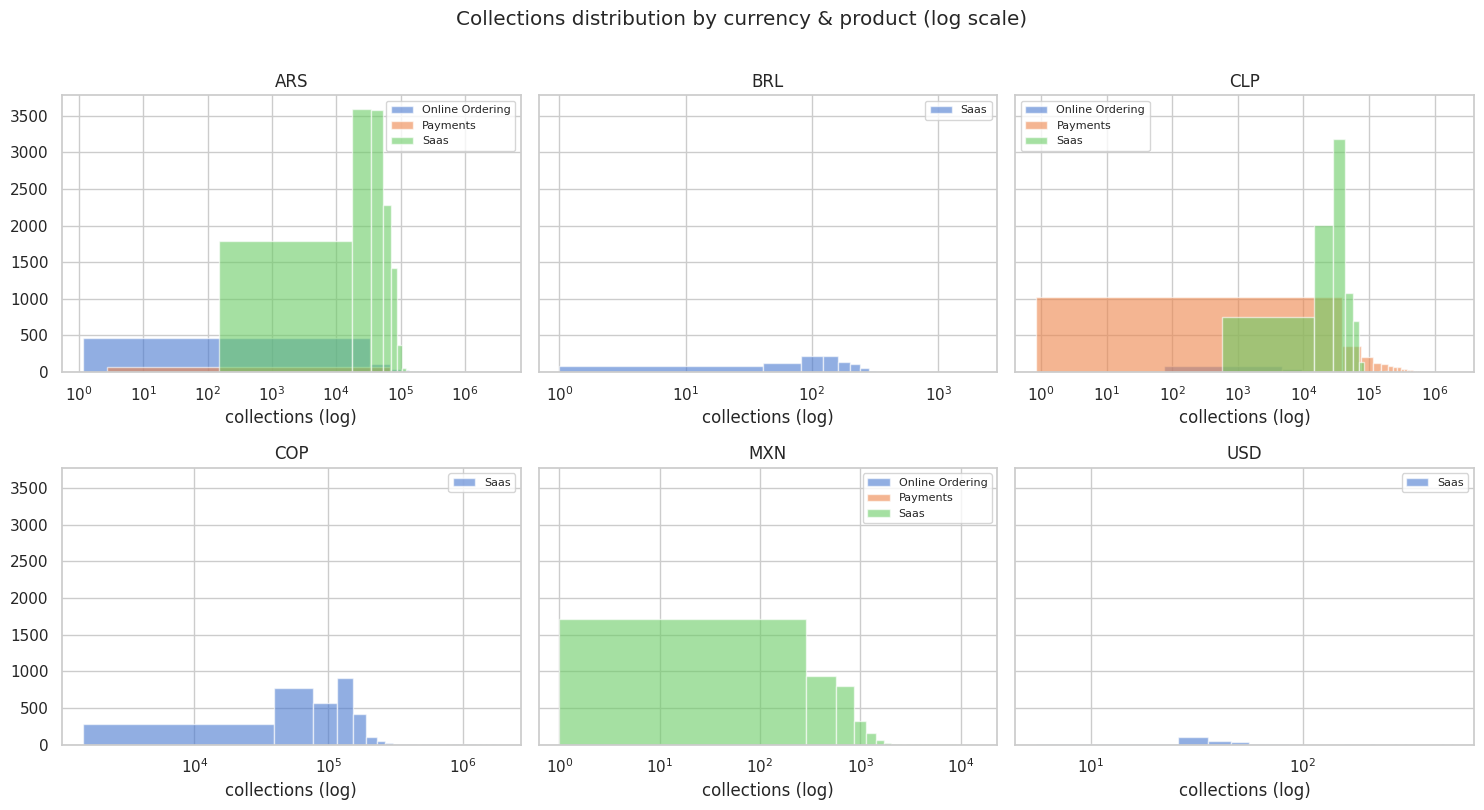

In [3]:
# Distributions are heavy-tailed and multi-currency, so log-scale + facet by currency
non_zero = df[df["collections"] > 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (currency, grp) in zip(axes.flat, non_zero.groupby("currency")):
    for product, pgrp in grp.groupby("product"):
        ax.hist(pgrp["collections"], bins=50, alpha=0.6, label=product, edgecolor="white")
    ax.set_xscale("log")
    ax.set_title(currency)
    ax.set_xlabel("collections (log)")
    ax.legend(fontsize=8)

# Hide unused subplot
if len(non_zero["currency"].unique()) < 6:
    axes.flat[-1].set_visible(False)

fig.suptitle("Collections distribution by currency & product (log scale)", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "collections_by_currency_product.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Monthly revenue by country & product

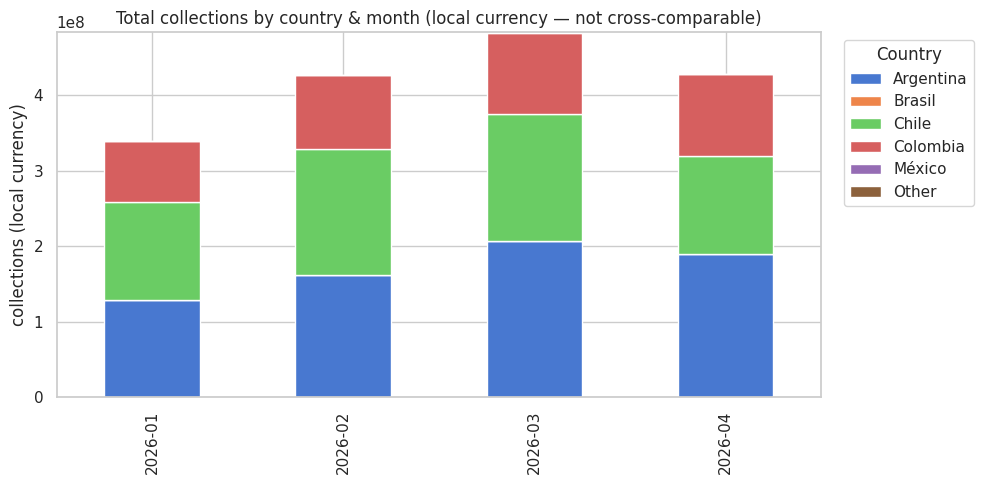

In [4]:
# Total collections per month, by country (in local currency — not cross-comparable)
monthly_country = (
    df.groupby(["transaction_date", "pais"])["collections"]
    .sum()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_country.plot.bar(ax=ax, stacked=True)
ax.set_title("Total collections by country & month (local currency — not cross-comparable)")
ax.set_ylabel("collections (local currency)")
ax.set_xlabel("")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_revenue_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Active accounts per month

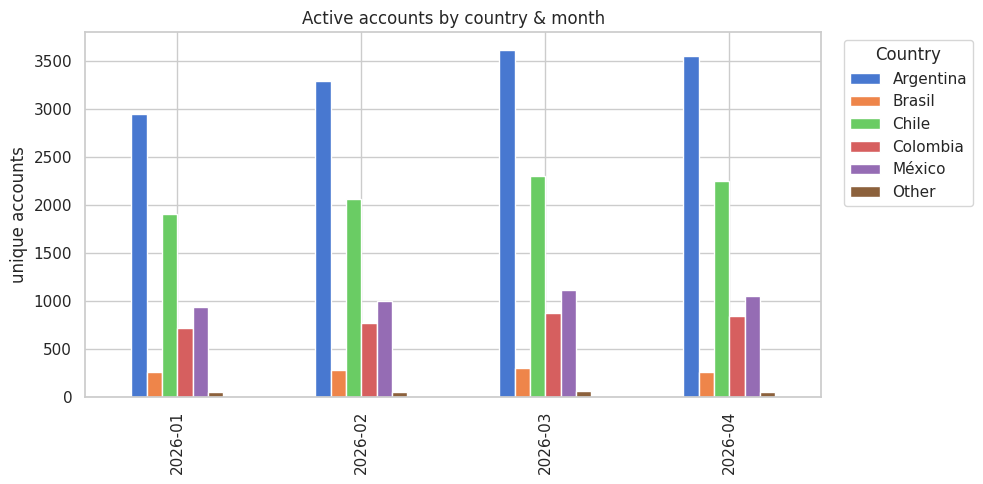

In [5]:
active_accounts = (
    df.groupby(["transaction_date", "pais"])["client_id"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
active_accounts.plot.bar(ax=ax)
ax.set_title("Active accounts by country & month")
ax.set_ylabel("unique accounts")
ax.set_xlabel("")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "active_accounts_by_country.png", dpi=150, bbox_inches="tight")
plt.show()